In [1]:
import os
import pandas as pd
import json
import joblib

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, fbeta_score

In [2]:
DATA_DIR = os.path.join("..", "data", "processed", "splits")
RESULTS_DIR = os.path.join("..", "data", "processed", "results")

X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_tree.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_tree.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))

In [3]:
base_rf = RandomForestClassifier(random_state=42)
base_rf.fit(X_train, y_train.squeeze())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [4]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_leaf_nodes": [None, 5, 10, 20],
    "max_features": ['sqrt', 'log2', None],
    "max_samples": [None, 0.8, 0.9]
}

rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42), 
    param_distributions=param_grid, 
    n_iter=100,
    cv=5, 
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1, 
    #n_jobs=max(1, int(os.cpu_count() * 0.75)),
    verbose=2
)

rf.fit(X_train, y_train.squeeze())

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'max_leaf_nodes': [None, 5, ...], 'max_samples': [None, 0.8, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [5]:
best_rf = rf.best_estimator_
print("Best Score:", rf.best_score_)
print("Best Hyperparameters:", rf.best_params_)

Best Score: 0.8994512481189696
Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_samples': None, 'max_leaf_nodes': 20, 'max_features': 'sqrt', 'max_depth': 10}


In [6]:
y_preds_base = base_rf.predict(X_test)
y_preds = best_rf.predict(X_test)

print("\n--- Base RF ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds_base))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
print(classification_report(y_test.squeeze(), y_preds_base))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), base_rf.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds_base))

print("\n--- Tuned RF ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds, beta=2))
print(classification_report(y_test.squeeze(), y_preds))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), best_rf.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds))


--- Base RF ---
Accuracy: 0.7802197802197802
F2 Score: 0.7770961145194274
              precision    recall  f1-score   support

           0       0.74      0.80      0.77        83
           1       0.82      0.77      0.79        99

    accuracy                           0.78       182
   macro avg       0.78      0.78      0.78       182
weighted avg       0.78      0.78      0.78       182

ROC-AUC: 0.8744675672386516
Confusion Matrix:
 [[66 17]
 [23 76]]

--- Tuned RF ---
Accuracy: 0.8296703296703297
F2 Score: 0.86
              precision    recall  f1-score   support

           0       0.83      0.78      0.81        83
           1       0.83      0.87      0.85        99

    accuracy                           0.83       182
   macro avg       0.83      0.83      0.83       182
weighted avg       0.83      0.83      0.83       182

ROC-AUC: 0.897651210904223
Confusion Matrix:
 [[65 18]
 [13 86]]


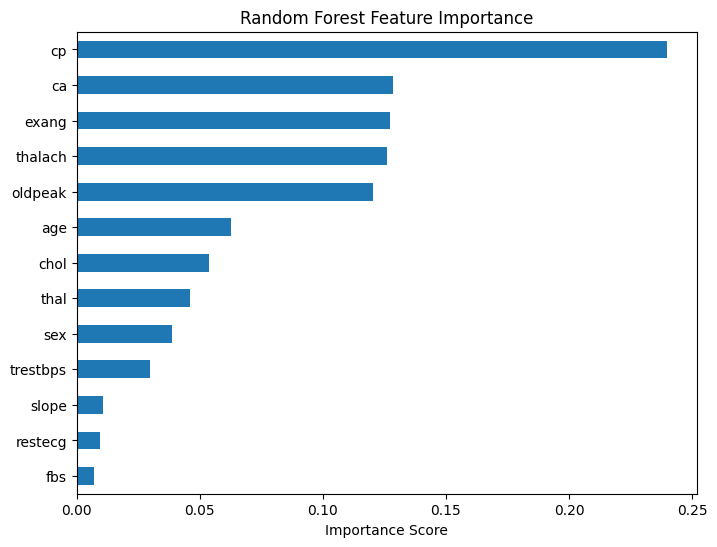

In [7]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.show()

In [8]:
joblib.dump(best_rf, '../models/random_forest.pkl')

rf_results = {
    'base_rf': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds_base)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), base_rf.predict_proba(X_test)[:, 1])),
        'f2': float(fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
    },
    'tuned_rf': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), best_rf.predict_proba(X_test)[:, 1])),
        'f2': float(fbeta_score(y_test.squeeze(), y_preds, beta=2))
    }
}

with open(os.path.join(RESULTS_DIR, 'rf_results.json'), 'w') as f:
    json.dump(rf_results, f, indent=4)